In [16]:
# Load the dataset 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/kathmandu_features.csv")
df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])

# Reconstruct a plain station label from the one-hot columns, for grouping/plotting
df["station"] = np.where(df["station_teku"], "teku", "mid_baneshwor")

print(df.shape)
df.head()

(8343, 26)


,datetime_utc,pm1,pm25,relativehumidity,temperature,um003,was_missing,hour,day_of_week,month,...,pm25_rolling_std_6h,pm25_rolling_mean_24h,pm25_rolling_std_24h,target_pm25_next_1h,WS10M,WD10M,PRECTOTCORR,station_mid_baneshwor,station_teku,station
0,2025-11-25 08:15:00,23.5,38.9,38.5,21.3,1370.0,False,8,1,11,...,NaN,38.900000,NaN,44.9,3.66,239.1,0.0,True,False,mid_baneshwor
1,2025-11-25 09:15:00,27.5,44.9,38.1,21.9,1790.0,False,9,1,11,...,4.242641,41.900000,4.242641,48.9,3.34,243.3,0.0,True,False,mid_baneshwor
2,2025-11-25 10:15:00,29.2,48.9,39.3,21.3,1980.0,False,10,1,11,...,5.033223,44.233333,5.033223,48.0,2.41,243.1,0.0,True,False,mid_baneshwor
3,2025-11-25 11:15:00,29.0,48.0,41.2,20.2,1980.0,False,11,1,11,...,4.520601,45.175000,4.520601,49.4,1.58,244.1,0.0,True,False,mid_baneshwor
4,2025-11-25 12:15:00,29.9,49.4,40.9,20.1,2060.0,False,12,1,11,...,4.347068,46.020000,4.347068,58.5,1.05,258.5,0.0,True,False,mid_baneshwor


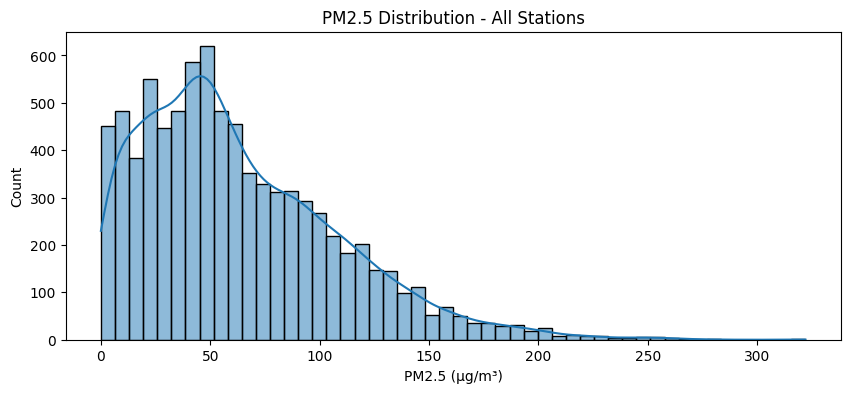

count    8312.000000
mean       63.259481
std        45.118415
min         0.000000
25%        28.800000
50%        53.600000
75%        90.000000
max       322.000000
Name: pm25, dtype: float64


In [19]:
# Overalll Distribution of PM2.5

plt.figure(figsize=(10, 4))
sns.histplot(df["pm25"], bins=50, kde=True)
plt.title("PM2.5 Distribution - All Stations")
plt.xlabel("PM2.5 (µg/m³)")
plt.show()

print(df["pm25"].describe())

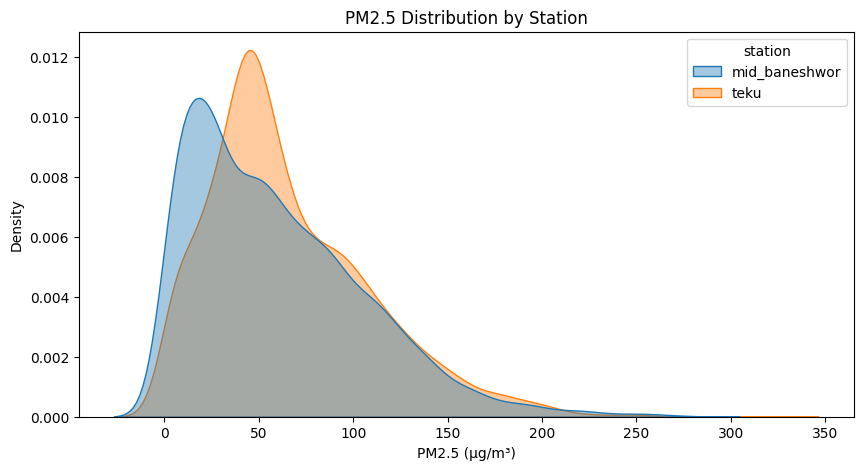

                count       mean        std  min   25%   50%    75%    max
station                                                                   
mid_baneshwor  3903.0  60.084166  46.574872  0.0  22.3  50.5  87.95  278.0
teku           4409.0  66.070381  43.601438  0.0  36.1  55.4  91.90  322.0


In [20]:
# Distribution by station

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="pm25", hue="station", fill=True, common_norm=False, alpha=0.4)
plt.title("PM2.5 Distribution by Station")
plt.xlabel("PM2.5 (µg/m³)")
plt.show()

print(df.groupby("station")["pm25"].describe())

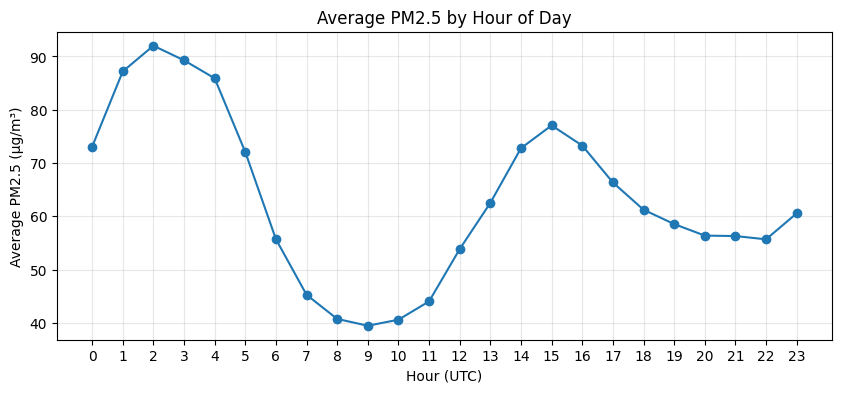

In [21]:
# Diurnal (hour of day) Pattern 

hourly_avg = df.groupby("hour")["pm25"].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour (UTC)")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

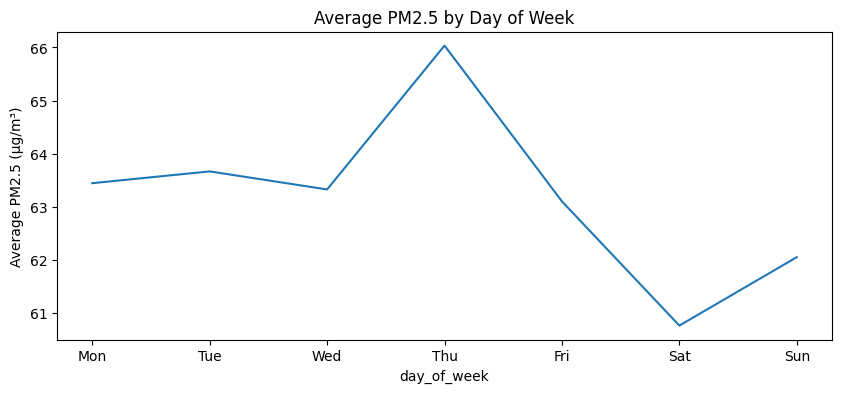

In [25]:
# Day of week pattern

dow_avg = df.groupby("day_of_week")["pm25"].mean()
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(10, 4))
dow_avg.plot(kind="line")
plt.xticks(range(7), dow_labels, rotation=0)
plt.title("Average PM2.5 by Day of Week")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.show()

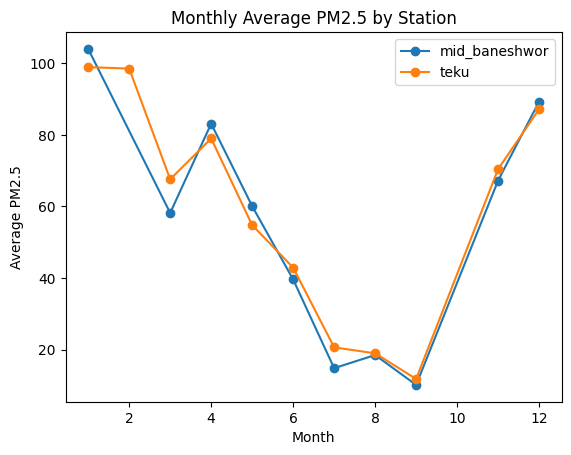

In [27]:
# Seasonal/ Time series patterns

station_cols = [c for c in df.columns if c.startswith("station_")]
if station_cols:
    for col in station_cols:
        subset = df[df[col] == 1]
        monthly = subset.groupby("month")["pm25"].mean()
        plt.plot(monthly.index, monthly.values, marker="o", label=col.replace("station_", ""))

plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Monthly Average PM2.5 by Station")
plt.legend()
plt.show()

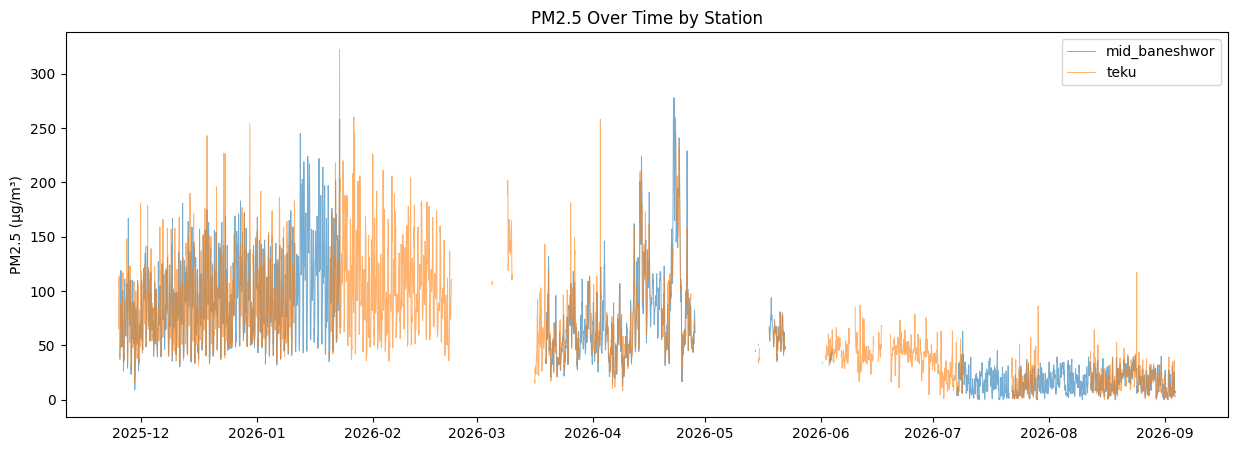

In [29]:
# Full series by station

fig, ax = plt.subplots(figsize=(15, 5))
for station, group in df.groupby("station"):
    ax.plot(group["datetime_utc"], group["pm25"], label=station, alpha=0.6, linewidth=0.7)
ax.legend()
ax.set_title("PM2.5 Over Time by Station")
ax.set_ylabel("PM2.5 (µg/m³)")
plt.show()

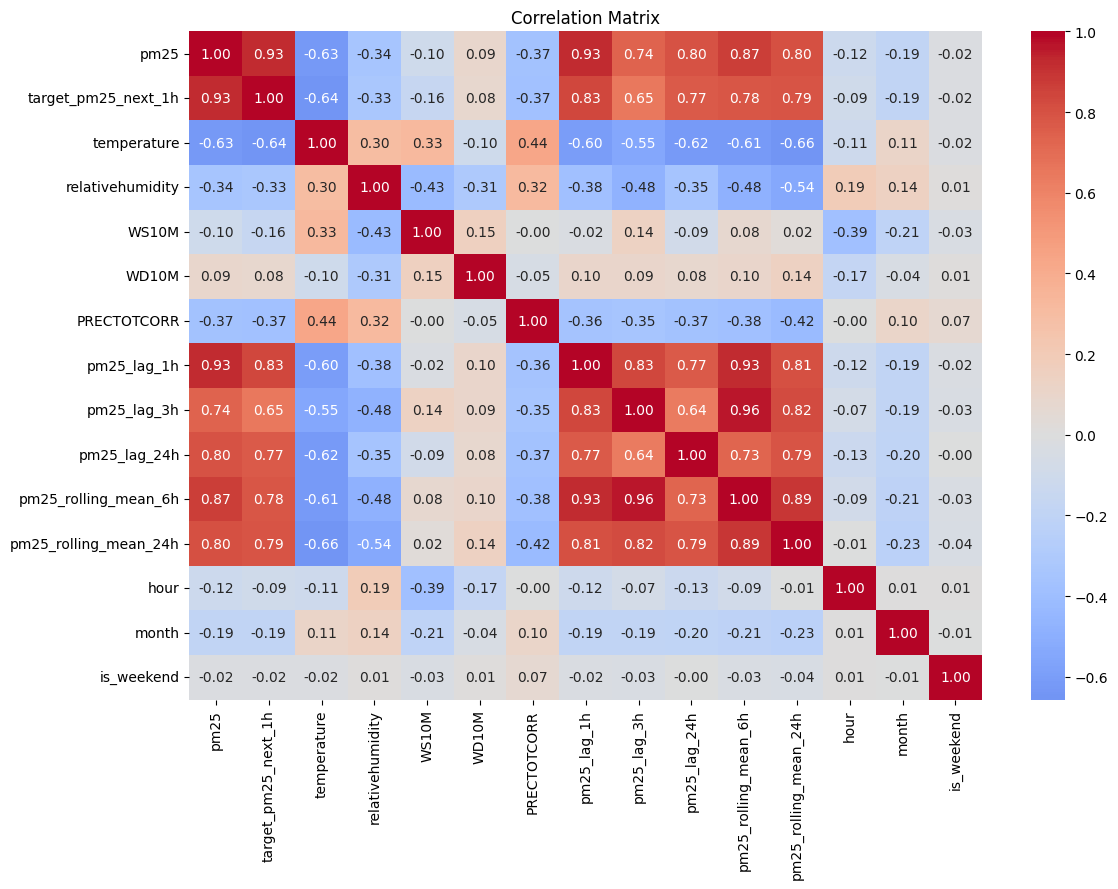

In [30]:
correlation_columns = [
    "pm25", "target_pm25_next_1h", "temperature", "relativehumidity",
    "WS10M", "WD10M", "PRECTOTCORR",
    "pm25_lag_1h", "pm25_lag_3h", "pm25_lag_24h",
    "pm25_rolling_mean_6h", "pm25_rolling_mean_24h",
    "hour", "month", "is_weekend"
]

corr = df[correlation_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

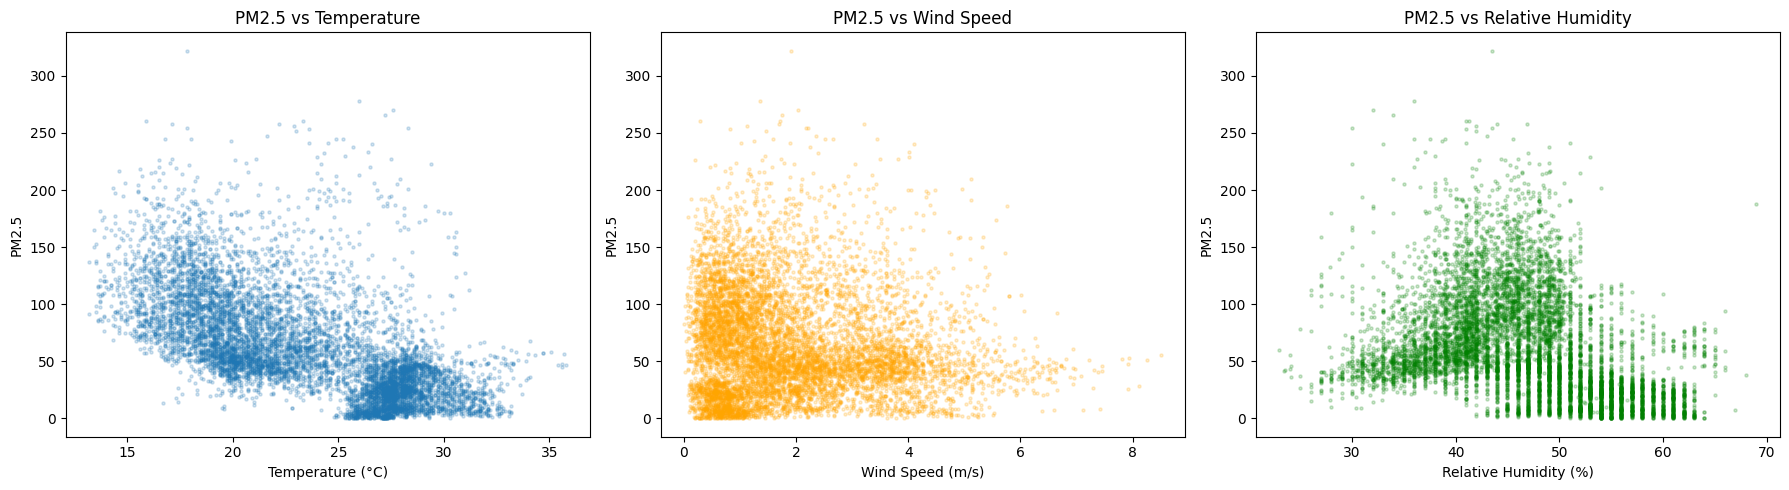

In [ ]:
# PM2.5 vs Weather variables (Scatter plots)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df["temperature"], df["pm25"], alpha=0.2, s=5)
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("PM2.5")
axes[0].set_title("PM2.5 vs Temperature")

axes[1].scatter(df["WS10M"], df["pm25"], alpha=0.2, s=5, color="orange")
axes[1].set_xlabel("Wind Speed (m/s)")
axes[1].set_ylabel("PM2.5")
axes[1].set_title("PM2.5 vs Wind Speed")

axes[2].scatter(df["relativehumidity"], df["pm25"], alpha=0.2, s=5, color="green")
axes[2].set_xlabel("Relative Humidity (%)")
axes[2].set_ylabel("PM2.5")
axes[2].set_title("PM2.5 vs Relative Humidity")

plt.tight_layout()
plt.show()

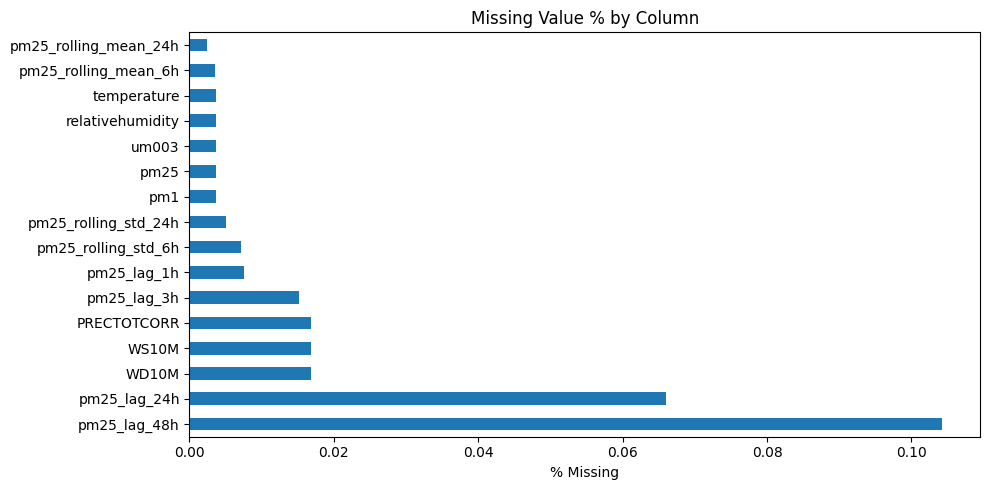

pm25_lag_48h             0.104279
pm25_lag_24h             0.066043
WD10M                    0.016900
WS10M                    0.016900
PRECTOTCORR              0.016900
pm25_lag_3h              0.015102
pm25_lag_1h              0.007551
pm25_rolling_std_6h      0.007192
pm25_rolling_std_24h     0.005034
pm1                      0.003716
pm25                     0.003716
um003                    0.003716
relativehumidity         0.003716
temperature              0.003716
pm25_rolling_mean_6h     0.003476
pm25_rolling_mean_24h    0.002397
dtype: float64


In [32]:
# Missingness review

missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 5))
missing_pct.plot(kind="barh")
plt.title("Missing Value % by Column")
plt.xlabel("% Missing")
plt.tight_layout()
plt.show()

print(missing_pct)

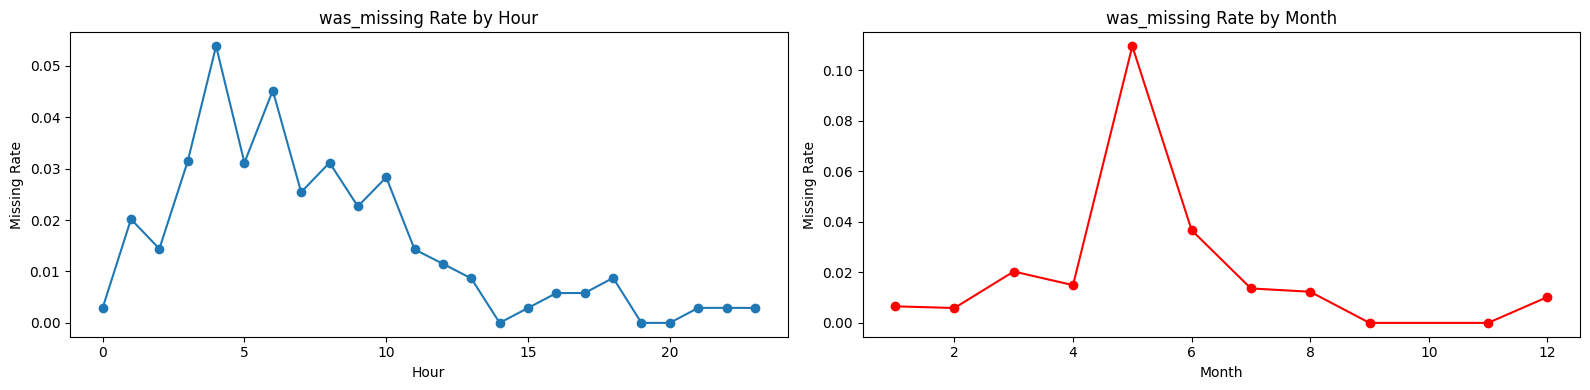

In [33]:
# was_missing rate by hour and month

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df.groupby("hour")["was_missing"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("was_missing Rate by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Missing Rate")

df.groupby("month")["was_missing"].mean().plot(ax=axes[1], marker="o", color="red")
axes[1].set_title("was_missing Rate by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Missing Rate")

plt.tight_layout()
plt.show()

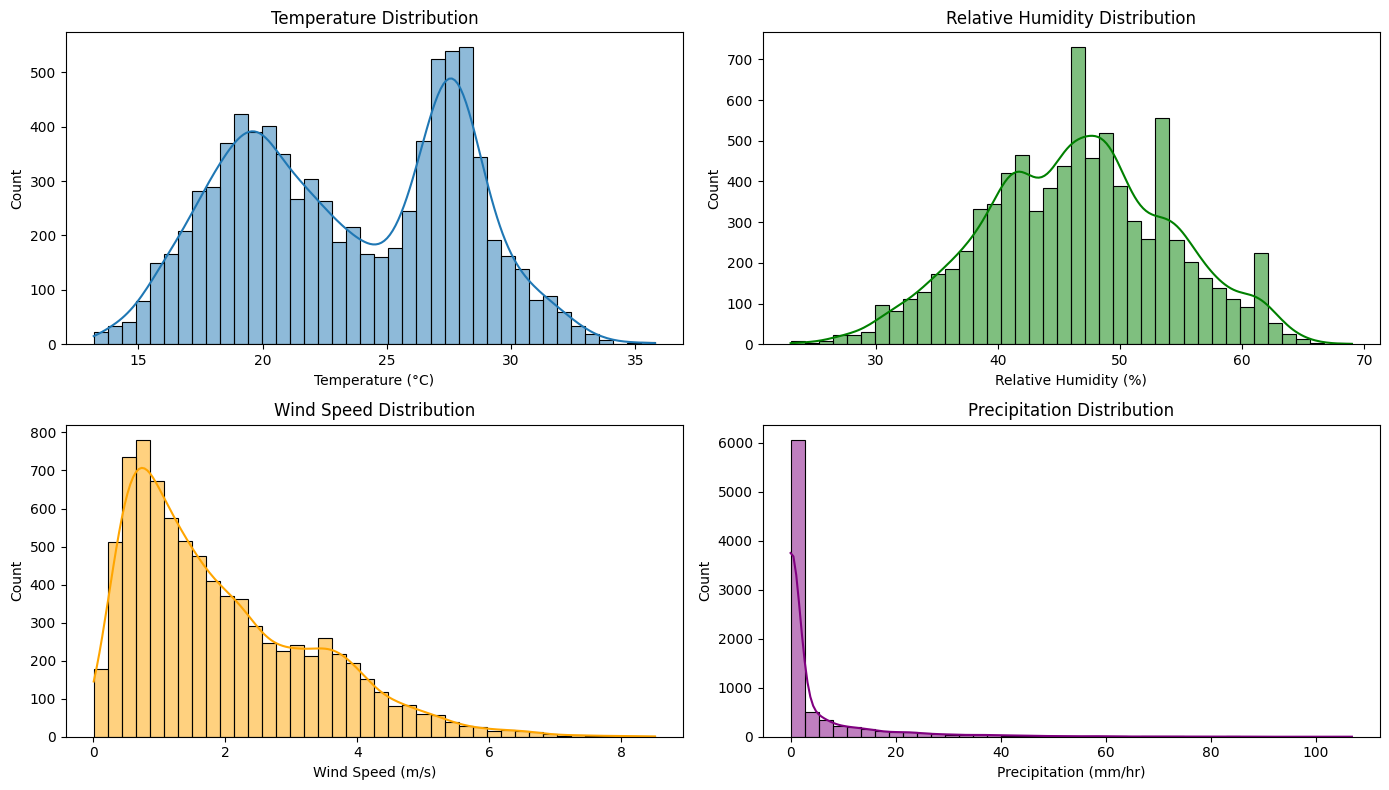

In [34]:
# Weather variable distributions

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df["temperature"].dropna(), bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Temperature Distribution")
axes[0, 0].set_xlabel("Temperature (°C)")

sns.histplot(df["relativehumidity"].dropna(), bins=40, kde=True, ax=axes[0, 1], color="green")
axes[0, 1].set_title("Relative Humidity Distribution")
axes[0, 1].set_xlabel("Relative Humidity (%)")

sns.histplot(df["WS10M"].dropna(), bins=40, kde=True, ax=axes[1, 0], color="orange")
axes[1, 0].set_title("Wind Speed Distribution")
axes[1, 0].set_xlabel("Wind Speed (m/s)")

sns.histplot(df["PRECTOTCORR"].dropna(), bins=40, kde=True, ax=axes[1, 1], color="purple")
axes[1, 1].set_title("Precipitation Distribution")
axes[1, 1].set_xlabel("Precipitation (mm/hr)")

plt.tight_layout()
plt.show()

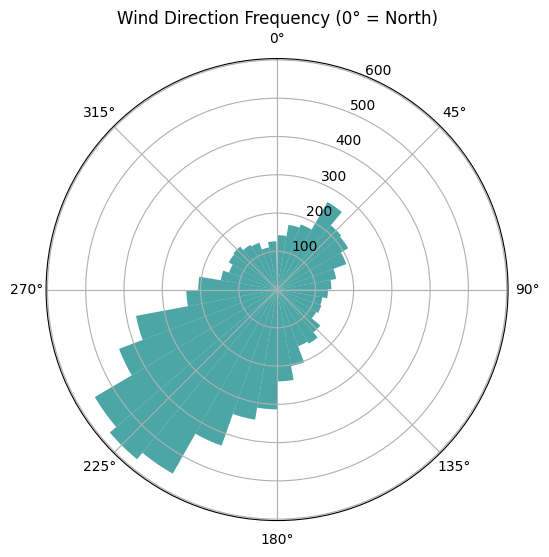

In [35]:
# Wind direction distribution

wind_dir_rad = np.deg2rad(df["WD10M"].dropna())

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection="polar")
ax.hist(wind_dir_rad, bins=36, color="teal", alpha=0.7)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title("Wind Direction Frequency (0° = North)")
plt.show()

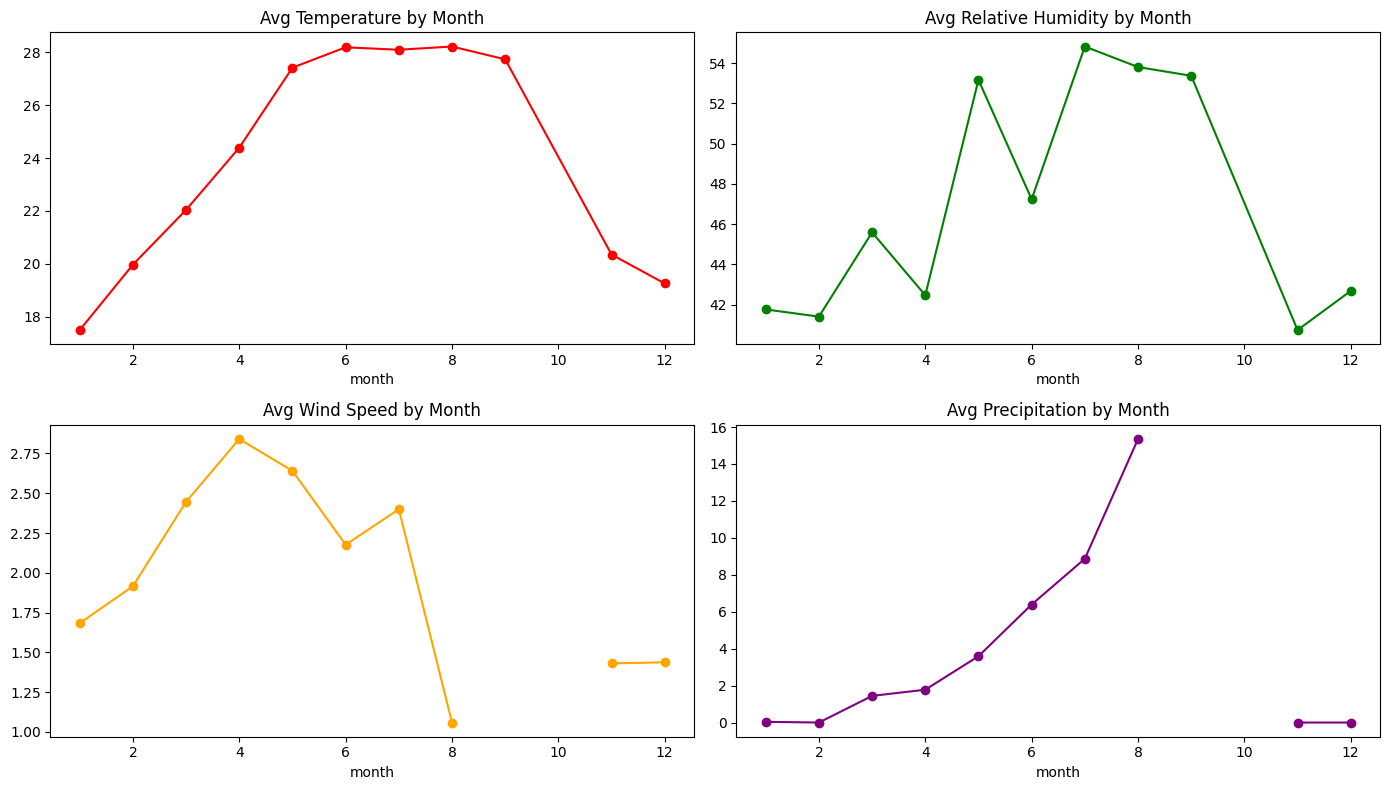

In [36]:
# Weather seasonality 

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df.groupby("month")["temperature"].mean().plot(ax=axes[0, 0], marker="o", color="red")
axes[0, 0].set_title("Avg Temperature by Month")

df.groupby("month")["relativehumidity"].mean().plot(ax=axes[0, 1], marker="o", color="green")
axes[0, 1].set_title("Avg Relative Humidity by Month")

df.groupby("month")["WS10M"].mean().plot(ax=axes[1, 0], marker="o", color="orange")
axes[1, 0].set_title("Avg Wind Speed by Month")

df.groupby("month")["PRECTOTCORR"].mean().plot(ax=axes[1, 1], marker="o", color="purple")
axes[1, 1].set_title("Avg Precipitation by Month")

plt.tight_layout()
plt.show()

In [37]:
# Weather comparison by station

weather_cols = ["temperature", "relativehumidity", "WS10M", "WD10M", "PRECTOTCORR"]
df.groupby("station")[weather_cols].mean()

,temperature,relativehumidity,WS10M,WD10M,PRECTOTCORR
station,,,,,
mid_baneshwor,23.367853,48.723518,1.880635,186.873523,5.530844
teku,23.402335,44.363434,1.975324,185.969296,3.133270


In [38]:
# Summary stats table

summary = df.groupby("station")[["pm25", "temperature", "relativehumidity", "WS10M", "PRECTOTCORR"]].describe().T
summary

station                 mid_baneshwor         teku
pm25             count    3903.000000  4409.000000
                 mean       60.084166    66.070381
                 std        46.574872    43.601438
                 min         0.000000     0.000000
                 25%        22.300000    36.100000
                 50%        50.500000    55.400000
                 75%        87.950000    91.900000
                 max       278.000000   322.000000
temperature      count    3903.000000  4409.000000
                 mean       23.367853    23.402335
                 std         5.066397     4.119367
                 min        13.200000    15.300000
                 25%        18.900000    19.800000
                 50%        23.800000    22.700000
                 75%        27.400000    27.500000
                 max        35.600000    35.800000
relativehumidity count    3903.000000  4409.000000
                 mean       48.723518    44.363434
                 std         7.557364     7.083161
                 min        24.000000    23.000000
                 25%        44.200000    39.700000
                 50%        48.500000    44.000000
                 75%        54.000000    50.000000
                 max        66.000000    69.000000
WS10M            count    3841.000000  4361.000000
                 mean        1.880635     1.975324
                 std         1.495913     1.293319
                 min         0.010000     0.030000
                 25%         0.690000     0.950000
                 50%         1.350000     1.700000
                 75%         2.840000     2.770000
                 max         7.570000     8.510000
PRECTOTCORR      count    3841.000000  4361.000000
                 mean        5.530844     3.133270
                 std        11.839701     8.178200
                 min         0.000000     0.000000
                 25%         0.000000     0.000000
                 50%         0.010000     0.000000
                 75%         5.210000     1.520000
                 max       102.010000   106.870000

Notes and observations:

- PM2.5 clearly higher Dec-Feb, drops through monsoon (Jun-Sep)= confirms seasonal burning signal
- Station Teku shows higher median PM2.5 than Station Mid Baneshwor
- Instead of rush hour pattern spike, the target was found higher around hours 2 and 15